In [1]:
#==========
# Import Libraries
#==========
import pandas as pd # load and clean data
import numpy as np # calclations and ML models
import matplotlib.pyplot as plt # basic plotting
import seaborn as sns # visualizations
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\archive (1)\Mall_Customers.csv")
# Preview data
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# ==========================
# Exploratory Data Analysis 
# ==========================
df.describe().T # summary statistics

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


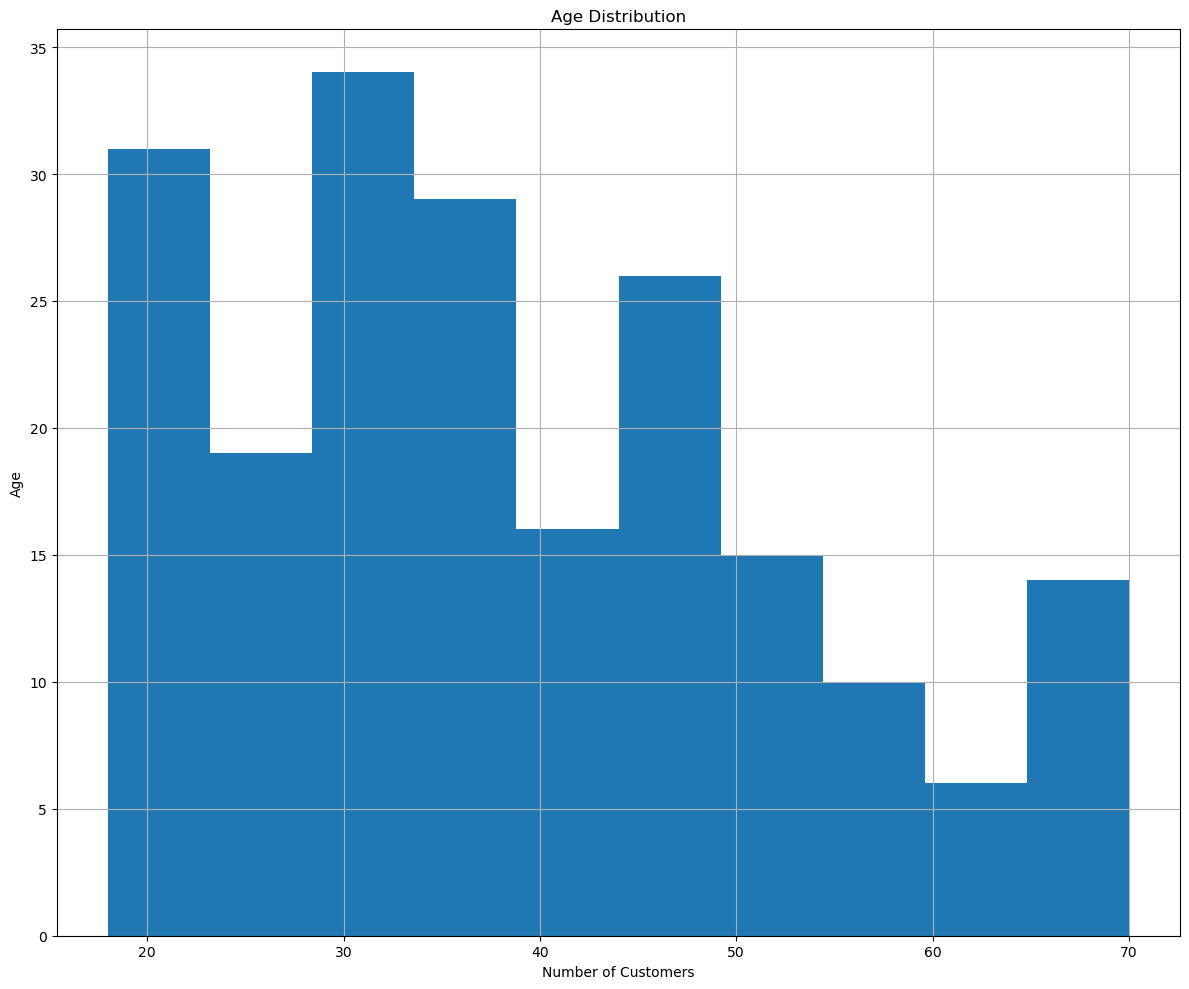

In [4]:
# =================
# Age Distribution
# =================
df['Age'].hist(figsize=(12,10))
plt.title("Age Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

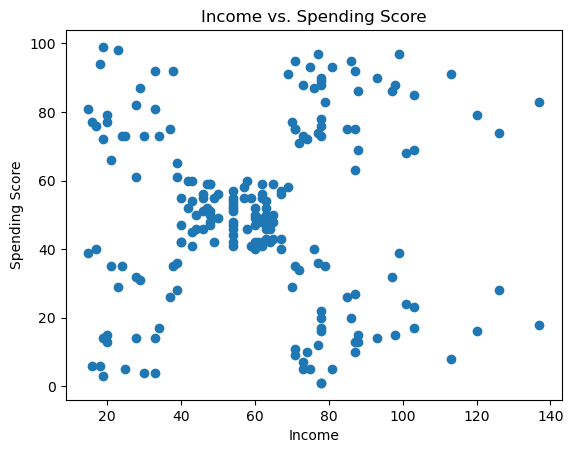

In [5]:
# =======================================
# Income vs Spending Score (scatter plot)
# =======================================
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title("Income vs. Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [6]:
# ===============
# Scaling Data
# ===============

# import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# load data

X = df[['Annual Income (k$)', 'Spending Score (1-100)']] 

# initialize scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# ===================
# K-means clustering
# ===================

# import necessary library
from sklearn.cluster import KMeans

# load dataX_scaled = scaler.fit_transform(X)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# train clustering model
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# label clusters
labels = kmeans.labels_
df['Cluster'] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


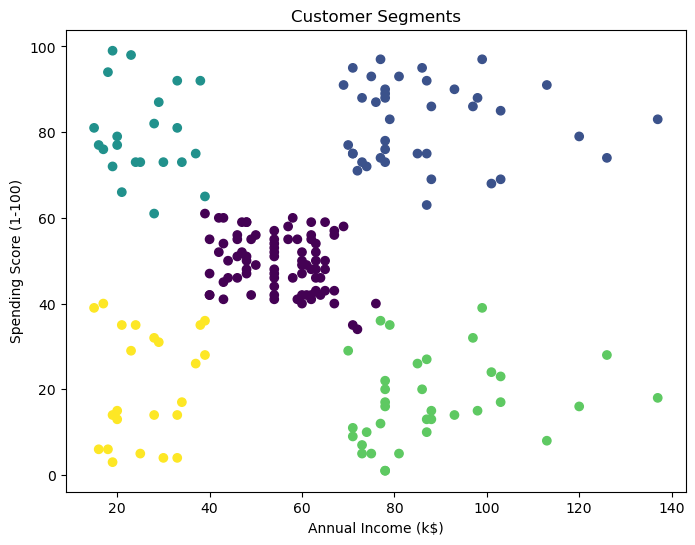

In [8]:
# ==================
# Visualize clusers
# ==================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.show()

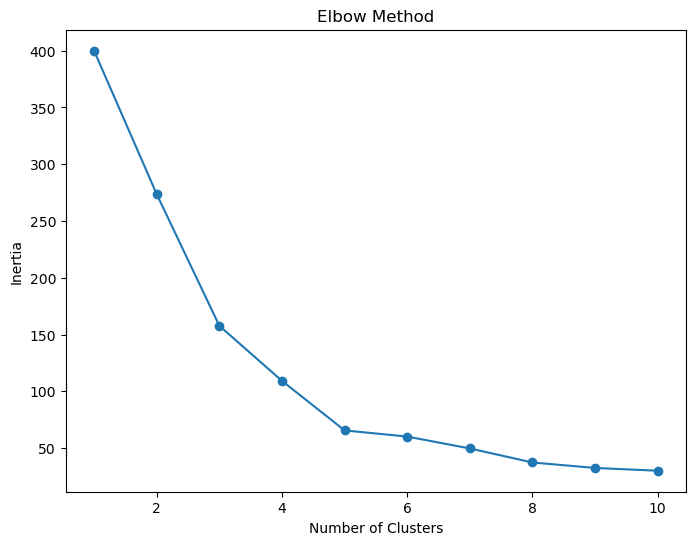

In [9]:
# ======================
# Elbow method
# ======================
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The elbow method shows a sharp decrease in inertia up to 4-5 clusters, after which the rate of improvement slows significantly. Therefore, 5 clusters were selected as a balance between model complexity and performance.

In [10]:
# ===================
# Summarize clusters
# ===================
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Customer segmentation using K-means clustering revealed five distinct groups based on average income and spending behavior. High-income, high-spending customers represent a premium segment and should be targeted with exclusive offers and loyalty programs. High-income but low-spending customers present an opportunity for conversion through personalized incentives. Low-income, high-spending customers may respond well to promotions and discounts, while low-income, low-spending customers represent a low-priority segment. Mid-income, moderate-spending customers provide stable revenue and should be maintained through consistent engagement strategies. 

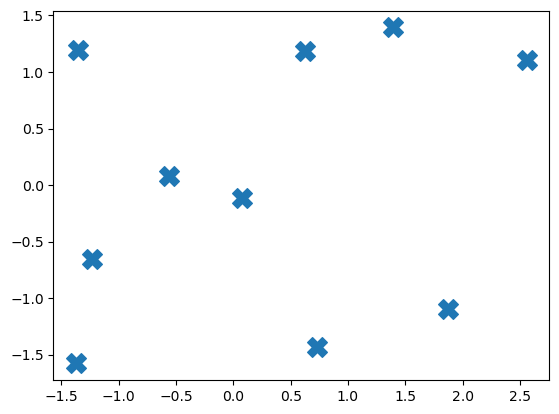

In [11]:
# =====================
# plot cluster centers
# =====================

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200,
    marker='X'
)